# Qiskit Example: Modeling $\textrm{N}_2$ with SQD

`H2_VQE_example.ipynb` ended on an uncomfortable note: run UCCSD through a
real device's calibrated noise and the energy comes out roughly $0.11$
Hartree **above** FCI -- worse than Hartree-Fock, recovering a negative
fraction of the correlation energy. That error is a *bias*, not scatter:
more shots shrink the spread around it but leave the offset untouched.

`H2_SQD_example.ipynb` attacked the same problem a different way:
**Sample-based Quantum Diagonalization** asks the quantum device for much
less -- not an expectation value, just a list of *which electronic
configurations matter*. It measures the ansatz in the computational basis,
collects the determinants that appear, projects the Hamiltonian onto their
span, and diagonalizes that small matrix classically and exactly. That
notebook came with an honest caveat, though: $\textrm{H}_2$/STO-3G's full
CI space is only 4 determinants, so any halfway-reasonable sampling spans
the *entire* space -- nothing is actually being *selected*.

This notebook moves to $\textrm{N}_2$/STO-3G with the 1s+2s core frozen: 12
active spin-orbitals, 6 active electrons, and a 400-determinant active-space
CI -- large enough that which determinants get sampled genuinely matters,
and small enough that the exact (CASCI) answer is still computable for
comparison.

The consequence is the whole point:

> Noise corrupts **which bitstrings** you see. It cannot corrupt the
> eigenvalue, because the eigenvalue never came from the device.

The result is variational -- an upper bound on the true ground-state
energy, approached from above as the subspace improves, and one that can
never fall below the exact active-space energy.

This notebook also drops the other thing `H2_SQD_example.ipynb` built by
hand: the classical SQD engine itself (the from-scratch Jordan-Wigner
Hamiltonian, determinant projection, configuration recovery, and the
iterate-and-diagonalize loop). At $\textrm{H}_2$'s scale, building that
engine by hand was the whole point -- showing exactly what SQD does under
the hood. At $\textrm{N}_2$'s scale it is not: the real
**`qiskit-addon-sqd`** package does all of it, tested and maintained, and
it works directly on molecular integrals rather than a qubit Hamiltonian --
there is no Jordan-Wigner Hamiltonian to build in the first place. Sections
0-2 build the active-space integrals and the UCCSD ansatz via
**`qiskit-nature`** (the same library `H2_SQD_example.ipynb` used for its
own ansatz); everything from Section 3 on hands those integrals to
`qiskit-addon-sqd` directly.

This notebook also does not attempt to variationally optimize the UCCSD
circuit. With 117 parameters, a real COBYLA run would not finish in any
reasonable time, and SQD does not need one anyway (Section 7b demonstrates
that directly, for this active space): every circuit below runs at
$\vec\theta=0$, the unoptimized, HF-collapsed ansatz.

## 0. Setup

In [1]:
import numpy as np
from itertools import combinations
%matplotlib inline
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

print("NumPy version:", np.__version__)
import pyscf
print("PySCF version:", pyscf.__version__)
import qiskit
print("Qiskit version:", qiskit.__version__)
import qiskit_aer
print("Qiskit Aer version:", qiskit_aer.__version__)
import qiskit_ibm_runtime
print("Qiskit IBM Runtime version:", qiskit_ibm_runtime.__version__)
import qiskit_nature
print("Qiskit Nature version:", qiskit_nature.__version__)
import importlib.metadata
print("Qiskit Addon SQD version:", importlib.metadata.version("qiskit-addon-sqd"))

NumPy version: 2.5.3
PySCF version: 2.14.0
Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2
Qiskit IBM Runtime version: 0.49.0
Qiskit Nature version: 0.8.0
Qiskit Addon SQD version: 0.13.1



## 1. Build the $\textrm{N}_2$ molecule and run Hartree-Fock

STO-3G (10 spatial orbitals, 20 spin-orbitals) at the experimental
equilibrium bond length 1.0977 Å. Section 2 freezes the 1s and 2s core
orbitals of both atoms, leaving a 12-spin-orbital active space.

In [2]:

from pyscf import gto, scf

mol = gto.M(atom='N 0 0 0; N 0 0 1.0977', basis='sto-3g', unit='Angstrom', verbose=0)
mf = scf.RHF(mol).run()

print(f"Molecule: N2, bond length 1.0977 Angstrom, basis STO-3G")
print(f"Number of electrons: {mol.nelectron}")
print(f"Number of spatial molecular orbitals: {mf.mo_coeff.shape[1]}")
print(f"Number of spin-orbitals (qubits needed): {2 * mf.mo_coeff.shape[1]}")
print(f"RHF total energy = {mf.e_tot:.8f} Hartree")


Molecule: N2, bond length 1.0977 Angstrom, basis STO-3G
Number of electrons: 14
Number of spatial molecular orbitals: 10
Number of spin-orbitals (qubits needed): 20
RHF total energy = -107.49589331 Hartree


## 2. Active-space integrals and Hamiltonian via Qiskit Nature

$\textrm{N}_2$/STO-3G has 10 spatial orbitals (20 spin-orbitals, 14
electrons) -- too large a Hilbert space ($2^{20}$) to sample usefully with
a single circuit. Freezing the 1s and 2s core orbitals of both atoms
leaves a 6-spatial-orbital (12 spin-orbital), 6-electron active space: 400
determinants, small enough for an exact classical comparison but large
enough that subspace *selection* is a real question.

`qiskit_nature`'s `ActiveSpaceTransformer` does the frozen-core reduction
directly -- give it the number of active electrons and active spatial
orbitals and it returns the **active-space** one- and two-body integrals
(`hcore`, `eri`) plus the constant energy shift (nuclear repulsion *and*
the frozen core's own contribution) that has to be added back to whatever
the active space computes. This replaces `H2_SQD_example.ipynb`'s
hand-written `apply_frozen_core` and the entire from-scratch Jordan-Wigner
Hamiltonian: `qiskit-addon-sqd` (Section 3 on) works directly on
`hcore`/`eri`, not on a qubit Pauli operator, so there is no qubit
Hamiltonian left to build.

In [3]:
from pyscf import mcscf
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

N_ACTIVE_ELECTRONS = 6    # freezes the 1s+2s core of both N atoms (4 spatial orbitals)
N_ACTIVE_SPATIAL = 6

driver = PySCFDriver(
    atom='N 0 0 0; N 0 0 1.0977', basis='sto3g',
    charge=0, spin=0, unit=DistanceUnit.ANGSTROM,
)
full_problem = driver.run()
transformer = ActiveSpaceTransformer(num_electrons=N_ACTIVE_ELECTRONS,
                                      num_spatial_orbitals=N_ACTIVE_SPATIAL)
problem = transformer.transform(full_problem)

n_mo = problem.num_spatial_orbitals
n_so = 2 * n_mo
n_alpha, n_beta = problem.num_particles
e_core_total = sum(problem.hamiltonian.constants.values())  # nuclear repulsion + frozen-core shift

ints = problem.hamiltonian.electronic_integrals
hcore = np.array(ints.alpha["+-"])
eri = np.array(ints.alpha["++--"])

print(f"full molecule: {full_problem.num_spatial_orbitals} spatial orbitals, "
      f"{sum(full_problem.num_particles)} electrons")
print(f"active space:  {n_mo} spatial orbitals ({n_so} qubits), "
      f"{n_alpha + n_beta} active electrons ({n_alpha} alpha, {n_beta} beta)")
print(f"energy constants (nuclear repulsion + frozen-core shift): {e_core_total:.8f} Hartree")
print(f"hcore shape: {hcore.shape}   eri shape: {eri.shape}")

e_casci = mcscf.CASCI(mf, N_ACTIVE_SPATIAL, N_ACTIVE_ELECTRONS).kernel()[0]
print(f"\n(for reference: PySCF CASCI({N_ACTIVE_ELECTRONS}e,{N_ACTIVE_SPATIAL}o) "
      f"with the same frozen core = {e_casci:.8f} Hartree)")

full molecule: 10 spatial orbitals, 14 electrons
active space:  6 spatial orbitals (12 qubits), 6 active electrons (3 alpha, 3 beta)
energy constants (nuclear repulsion + frozen-core shift): -96.21842996 Hartree
hcore shape: (6, 6)   eri shape: (6, 6, 6, 6)

(for reference: PySCF CASCI(6e,6o) with the same frozen core = -107.62184886 Hartree)


### 2a. UCCSD ansatz via Qiskit Nature

`HartreeFock` + `UCCSD` build the same kind of ansatz `H2_SQD_example.ipynb`
used for $\textrm{H}_2$, generalized automatically to however many active
electrons and orbitals the active space has -- no hand-written
`generate_excitations` needed. For this active space (3 occupied + 3
virtual spatial orbitals per spin), that is 18 singles and 99 doubles:
**117** variational parameters, against $\textrm{H}_2$'s 3.

None of them get optimized. A 117-parameter COBYLA run would not finish in
any reasonable time even on an exact simulator, and SQD does not need a
well-optimized circuit anyway (Section 7b demonstrates that directly for
this active space) -- every circuit below runs at $\vec\theta=0$.

In [4]:
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.mappers import JordanWignerMapper

mapper = JordanWignerMapper()
hf_state = HartreeFock(n_mo, (n_alpha, n_beta), mapper)
ansatz = UCCSD(n_mo, (n_alpha, n_beta), mapper, initial_state=hf_state)
n_singles = sum(1 for exc in ansatz.excitation_list if len(exc[0]) == 1)
n_doubles = sum(1 for exc in ansatz.excitation_list if len(exc[0]) == 2)
qc_uccsd = ansatz.decompose(reps=3)
params = list(qc_uccsd.parameters)

print(f"UCCSD circuit: {qc_uccsd.num_qubits} qubits, {len(params)} variational "
      f"parameters ({n_singles} singles, {n_doubles} doubles)")
print(f"circuit depth: {qc_uccsd.depth()}, total gate count: {qc_uccsd.size()}")

UCCSD circuit: 12 qubits, 117 variational parameters (18 singles, 99 doubles)
circuit depth: 14109, total gate count: 24138


## 3. Determinants, and handing the Hamiltonian to `qiskit-addon-sqd`

A **determinant** is still just an occupation pattern -- which spin-orbitals
hold an electron -- stored as a plain Python `int` whose bit $q$ is the
occupation of spin-orbital $q$, exactly as in `H2_SQD_example.ipynb`. That
notebook then spent a full section projecting the Hamiltonian onto a
determinant subspace by hand, using the Jordan-Wigner Pauli operator
directly. None of that machinery exists here:
`qiskit_addon_sqd.fermion.solve_fermion` diagonalizes the active-space
Hamiltonian in a subspace of determinants directly from `hcore`/`eri`,
using PySCF's own CI machinery underneath -- there is no qubit Hamiltonian
to build or project in the first place.

What is still needed is a handful of small, purely classical bit-twiddling
helpers -- splitting a determinant into its $\alpha$/$\beta$ halves,
counting electrons, building the Hartree-Fock determinant -- since Section
5 onward still needs to look at raw sampled bitstrings and check whether
they conserve particle number. These are generic and short enough that
writing them by hand costs nothing and does not pull in another dependency
just for bit arithmetic.

In [5]:
def split_spin(state, n_mo):
    '''(alpha_part, beta_part) of a determinant, each an n_mo-bit int.'''
    mask = (1 << n_mo) - 1
    return state & mask, (state >> n_mo) & mask

def popcount(x):
    return bin(x).count("1")

def electron_counts(state, n_mo):
    a, b = split_spin(state, n_mo)
    return popcount(a), popcount(b)

def has_correct_particle_number(state, n_mo, n_alpha, n_beta):
    na, nb = electron_counts(state, n_mo)
    return na == n_alpha and nb == n_beta

def hf_determinant(n_mo, n_alpha, n_beta):
    s = 0
    for p in range(n_alpha):
        s |= 1 << p
    for p in range(n_beta):
        s |= 1 << (n_mo + p)
    return s

print(f"n_alpha = {n_alpha}, n_beta = {n_beta}")
print("bit-manipulation helpers defined; the SQD engine itself is qiskit-addon-sqd's.")

n_alpha = 3, n_beta = 3
bit-manipulation helpers defined; the SQD engine itself is qiskit-addon-sqd's.


### 3a. Validate against known answers

Two checks with no quantum device involved at all, using
`qiskit_addon_sqd.fermion.solve_fermion` directly on hand-picked
determinant subspaces: the HF determinant on its own must give exactly the
RHF energy, and the full 400-determinant active-space CI must give exactly
`mcscf.CASCI` restricted to the same frozen core.

In [6]:
import time
from qiskit_addon_sqd.fermion import solve_fermion

def dets_to_bitstring_matrix(dets, n_mo):
    '''Convert a list of (alpha_occ_tuple, beta_occ_tuple) pairs into the bool
    matrix solve_fermion expects: columns [0, n_mo) = beta, [n_mo, 2n_mo) = alpha.
    WITHIN each half, qiskit_addon_sqd.fermion.bitstring_matrix_to_ci_strs (called
    internally by solve_fermion) treats the LEFTMOST column as the most-significant
    bit -- i.e. orbital p lives at column offset (n_mo - 1 - p), not p. Verified
    directly against PySCF RHF/CASCI below; getting this backwards silently
    diagonalizes the wrong determinants (orbitals occupied <-> virtual, swapped).'''
    mat = np.zeros((len(dets), 2 * n_mo), dtype=bool)
    for i, (a_occ, b_occ) in enumerate(dets):
        for p in a_occ:
            mat[i, n_mo + (n_mo - 1 - p)] = True
        for p in b_occ:
            mat[i, n_mo - 1 - p] = True
    return mat

hf_bitstring = dets_to_bitstring_matrix(
    [(tuple(range(n_alpha)), tuple(range(n_beta)))], n_mo)
e_hf_elec, _, _, _ = solve_fermion(hf_bitstring, hcore=hcore, eri=eri)
e_hf_sub = e_hf_elec + e_core_total

# every determinant with the right electron count -- the full active-space CI
all_dets = [(a_occ, b_occ) for a_occ in combinations(range(n_mo), n_alpha)
                           for b_occ in combinations(range(n_mo), n_beta)]
all_bitstring_matrix = dets_to_bitstring_matrix(all_dets, n_mo)

_t0 = time.time()
e_full_elec, vec_full, occ_full, _ = solve_fermion(all_bitstring_matrix, hcore=hcore, eri=eri)
e_full_sub = e_full_elec + e_core_total
print(f"[timing] solve_fermion over the full {len(all_dets)}-determinant space: "
      f"{time.time() - _t0:.1f}s")

print(f"full active-space CI: {len(all_dets)} determinants")
print(f"\nHF determinant alone : {e_hf_sub:.8f} Ha   PySCF RHF = {mf.e_tot:.8f}"
      f"   diff {abs(e_hf_sub - mf.e_tot):.2e}")
print(f"all {len(all_dets)} determinants  : {e_full_sub:.8f} Ha   PySCF CASCI = {e_casci:.8f}"
      f"   diff {abs(e_full_sub - e_casci):.2e}")
print("\nthe classical engine (qiskit-addon-sqd) is exact; everything below is")
print("about which determinants the noisy device manages to find.")

[timing] solve_fermion over the full 400-determinant space: 0.0s
full active-space CI: 400 determinants

HF determinant alone : -107.49589331 Ha   PySCF RHF = -107.49589331   diff 5.68e-14
all 400 determinants  : -107.62184886 Ha   PySCF CASCI = -107.62184886   diff 6.25e-13

the classical engine (qiskit-addon-sqd) is exact; everything below is
about which determinants the noisy device manages to find.


## 4. Build the noisy simulator from a real IBM backend

Identical to the VQE notebook: `AerSimulator.from_backend` carries the
device's live calibration -- per-qubit $T_1$/$T_2$, per-gate error rates,
per-qubit readout confusion, the heavy-hex coupling map and the native
$R_z/\sqrt{X}/X$/CZ instruction set.

One deliberate difference: the backend is **pinned by name** rather than
chosen with `least_busy`. The VQE notebook's closing discussion showed that
letting the device float makes runs incomparable -- the same cell varied by
more across backends than the quantities being compared. Pin it here so the
SQD and VQE numbers refer to the same hardware.

In [7]:

import time
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit import transpile

ACCOUNT = "ibm-cloud-yahoo"
BACKEND_NAME = "ibm_kingston"   # set to None to fall back to least_busy

service = QiskitRuntimeService(name=ACCOUNT)
backend = service.backend(BACKEND_NAME) if BACKEND_NAME else \
          service.least_busy(operational=True, simulator=False)
sim = AerSimulator.from_backend(backend)

nm = sim.options.noise_model
print(f"backend: {backend.name} -- {backend.num_qubits} qubits, "
      f"{backend.status().pending_jobs} job(s) queued")
print(f"noise on {len(nm.noise_instructions)} instruction types across "
      f"{len(nm.noise_qubits)} qubits")

# theta=0 for every parameter -- Section 2a explains why no optimization was
# attempted at all (117 parameters, would not finish in reasonable time), and
# Section 7b confirms directly that SQD does not need a well-optimized circuit.
theta_opt = [0.0] * len(params)
qc_bound = qc_uccsd.assign_parameters(dict(zip(params, theta_opt)))

_t0 = time.time()
qc_isa = transpile(qc_bound, backend=sim, optimization_level=2, seed_transpiler=42)
print(f"[timing] transpile: {time.time() - _t0:.1f}s")
layout = qc_isa.layout.final_index_layout()
before = {k: v for k, v in qc_bound.count_ops().items() if k != 'barrier'}
after = {k: v for k, v in qc_isa.count_ops().items() if k != 'barrier'}
print(f"\ntranspiled to device ISA: depth {qc_bound.depth()} -> {qc_isa.depth()}")
print(f"  {before}")
print(f"  -> {after}")
print(f"  logical qubits 0..{n_so-1} sit on physical qubits {layout}")

backend: ibm_kingston -- 156 qubits, 1 job(s) queued
noise on 11 instruction types across 156 qubits
[timing] transpile: 0.3s

transpiled to device ISA: depth 14109 -> 6879
  {'cx': 10344, 'u': 3246, 'sdg': 3240, 'h': 3240, 's': 3240, 'p': 828}
  -> {'sx': 3595, 'cz': 2973, 'rz': 2620, 'x': 824}
  logical qubits 0..11 sit on physical qubits [91, 10, 149, 46, 45, 42, 44, 43, 41, 36, 21, 20]


## 5. Sample determinants from the noisy circuit

**This cell is slow.** Sampling 10,000 shots against a full noise-model
simulation of a circuit this deep took ~244s (~4 minutes) in a previous
run -- the noise channels, not the shot count itself, are the bottleneck.

Here is the first real difference from VQE. VQE needed *hundreds* of
circuit executions -- one per energy evaluation, each split across several
commuting Pauli groups, driven by an optimizer. SQD needs **one circuit,
measured once** in the computational basis.

Two details matter:

- The transpiled circuit spans all of the device's physical qubits, so we
  must measure only the handful carrying our logical qubits, in logical
  order. `qc_isa.layout.final_index_layout()` gives that mapping.
- Qiskit returns the bitstring with clbit 0 **rightmost**, which is exactly
  our bit-$q$-is-qubit-$q$ integer convention, so `int(bitstring, 2)` is
  already the determinant.

In [8]:

import time
from qiskit import ClassicalRegister

# kept modest so a first end-to-end run finishes quickly -- this same value
# drives Section 7b's sweep. Raise toward 50_000-100_000 once everything
# below runs cleanly; the [timing] prints tell you which stage to watch.
SHOTS = 10000
SEED = 42

def sample_determinants(circuit, simulator, shots, n_so, layout=None, seed=None):
    qc = circuit.copy()
    targets = list(range(n_so)) if layout is None else list(layout)
    if len(targets) != n_so:
        raise ValueError(f"layout has {len(targets)} qubits, expected {n_so}")
    qc.add_register(ClassicalRegister(n_so, 'meas'))
    qc.measure(targets, list(range(n_so)))
    run_opts = {} if seed is None else {"seed_simulator": seed}
    result = simulator.run(qc, shots=shots, **run_opts).result()
    counts = {}
    for bitstr, c in result.get_counts().items():
        state = int(bitstr.replace(" ", ""), 2)
        counts[state] = counts.get(state, 0) + c
    return counts

_t0 = time.time()
raw_counts = sample_determinants(qc_isa, sim, SHOTS, n_so, layout=layout, seed=SEED)
print(f"[timing] sample_determinants ({SHOTS} shots): {time.time() - _t0:.1f}s")

total = sum(raw_counts.values())
print(f"{total} shots produced {len(raw_counts)} distinct bitstrings\n")
print(f"{'bitstring':>12s}{'count':>8s}{'freq':>9s}   (n_alpha, n_beta)   valid?")
for state, c in sorted(raw_counts.items(), key=lambda kv: -kv[1]):
    na, nb = electron_counts(state, n_mo)
    ok = has_correct_particle_number(state, n_mo, n_alpha, n_beta)
    print(f"{format(state, f'0{n_so}b'):>12s}{c:8d}{c/total:9.4f}        "
          f"({na}, {nb})        {'yes' if ok else 'NO'}")

n_bad = sum(c for s, c in raw_counts.items()
            if not has_correct_particle_number(s, n_mo, n_alpha, n_beta))
print(f"\nshots with the WRONG electron count: {n_bad} / {total} "
      f"({100*n_bad/total:.2f}%)")
print("these are pure noise artefacts -- the exact circuit conserves particle")
print("number, so every one of them is a gate or readout error made visible.")

[timing] sample_determinants (10000 shots): 242.2s
10000 shots produced 573 distinct bitstrings

   bitstring   count     freq   (n_alpha, n_beta)   valid?
110111000111     103   0.0103        (3, 5)        NO
010111000111     101   0.0101        (3, 4)        NO
000111000111      99   0.0099        (3, 3)        yes
000011000111      96   0.0096        (3, 2)        NO
101111000111      95   0.0095        (3, 5)        NO
100011000111      94   0.0094        (3, 3)        yes
001011000111      94   0.0094        (3, 3)        yes
110011000111      93   0.0093        (3, 4)        NO
010011000111      91   0.0091        (3, 3)        yes
101011000111      90   0.0090        (3, 4)        NO
010101000111      85   0.0085        (3, 3)        yes
100101000111      83   0.0083        (3, 3)        yes
000001000111      83   0.0083        (3, 1)        NO
100001000111      82   0.0082        (3, 2)        NO
100111000111      82   0.0082        (3, 4)        NO
001101000111      81   0.008

## 6. Post-selection with `qiskit-addon-sqd`

The noisy samples contain bitstrings with the wrong number of electrons.
`H2_SQD_example.ipynb` implemented post-selection and configuration
recovery (S-CORE) by hand; here both come from `qiskit-addon-sqd` directly.

**Post-selection** simply throws bad shots away --
`qiskit_addon_sqd.subsampling.postselect_by_hamming_right_and_left` keeps
only bitstrings whose $\alpha$ and $\beta$ halves each have the right
Hamming weight. Simple, unbiased, and wasteful: on a circuit this deep the
discard rate can climb toward 100%, at which point there are no samples
left. As a baseline, this section also diagonalizes the post-selected-only
subspace once, with no iteration and no recovery -- Section 7 compares that
against the full iterative loop.

In [9]:
from qiskit.primitives import BitArray
from qiskit_addon_sqd.fermion import bit_array_to_arrays
from qiskit_addon_sqd.subsampling import postselect_by_hamming_right_and_left

bit_array = BitArray.from_counts({format(s, f'0{n_so}b'): c for s, c in raw_counts.items()})
matrix_all, probs_all = bit_array_to_arrays(bit_array)
matrix_ps, probs_ps = postselect_by_hamming_right_and_left(
    matrix_all, probs_all, hamming_right=n_alpha, hamming_left=n_beta)

print(f"post-selection: {len(matrix_ps)} of {len(matrix_all)} distinct bitstrings "
      f"survive ({n_bad} / {total} shots discarded, {100*n_bad/total:.2f}%)")

e_ps_elec, _, _, _ = solve_fermion(matrix_ps, hcore=hcore, eri=eri)
e_ps = e_ps_elec + e_core_total
print(f"post-selection-only energy: {e_ps:.8f} Ha   vs CASCI {e_ps - e_casci:+.2e}"
      f"   subspace dim <= {len(matrix_ps)}")

post-selection: 33 of 573 distinct bitstrings survive (8516 / 10000 shots discarded, 85.16%)
post-selection-only energy: -107.62184886 Ha   vs CASCI +6.25e-13   subspace dim <= 33


## 7. The SQD loop, via `qiskit_addon_sqd.fermion.diagonalize_fermionic_hamiltonian`

`H2_SQD_example.ipynb` hand-wrote the iterate-and-diagonalize loop: clean
the samples using the current occupancies, diagonalize in the resulting
subspace, read new occupancies off the ground state, repeat. That entire
loop -- subsampling, configuration recovery, batched diagonalization,
convergence checking -- is what
`qiskit_addon_sqd.fermion.diagonalize_fermionic_hamiltonian` does in a
single call. `num_batches` controls how many independently-recovered
subspaces are diagonalized *per iteration* (their results inform the next
iteration's occupancy estimate, and large-weight configurations carry over
between iterations via `carryover_threshold`), and `callback` exposes each
iteration's per-batch results for the progress printout below.

In [10]:
from qiskit_addon_sqd.fermion import diagonalize_fermionic_hamiltonian

sqd_history = []

def _progress_callback(results):
    energies = [r.energy + e_core_total for r in results]
    dims = [len(r.sci_state.ci_strs_a) * len(r.sci_state.ci_strs_b) for r in results]
    sqd_history.append({"energies": energies, "dims": dims})
    print(f"  iteration {len(sqd_history):2d}:  {len(results)} batch(es)  "
          f"best E={min(energies):.8f}  dims={dims}")

result_sqd = diagonalize_fermionic_hamiltonian(
    hcore, eri, bit_array, samples_per_batch=300, norb=n_mo, nelec=(n_alpha, n_beta),
    num_batches=5, max_iterations=10, callback=_progress_callback, seed=SEED,
)
e_sqd = result_sqd.energy + e_core_total
dim_sqd = len(result_sqd.sci_state.ci_strs_a) * len(result_sqd.sci_state.ci_strs_b)

print(f"\n{'':24s}{'E (Ha)':>13s}{'vs CASCI':>12s}{'subspace':>10s}")
print(f"{'SQD (qiskit-addon-sqd)':24s}{e_sqd:13.8f}{e_sqd - e_casci:+12.2e}{dim_sqd:10d}")
print(f"{'post-selection only':24s}{e_ps:13.8f}{e_ps - e_casci:+12.2e}{len(matrix_ps):10d}")
print(f"{'PySCF CASCI':24s}{e_casci:13.8f}{0.0:+12.2e}{len(all_dets):10d}")

  iteration  1:  5 batch(es)  best E=-107.57400889  dims=[140, 140, 140, 140, 140]
  iteration  2:  5 batch(es)  best E=-107.57751129  dims=[180, 180, 180, 180, 180]
  iteration  3:  5 batch(es)  best E=-107.60951348  dims=[200, 200, 200, 200, 200]
  iteration  4:  5 batch(es)  best E=-107.60951348  dims=[200, 200, 200, 200, 200]

                               E (Ha)    vs CASCI  subspace
SQD (qiskit-addon-sqd)  -107.60951348   +1.23e-02       200
post-selection only     -107.62184886   +6.25e-13        33
PySCF CASCI             -107.62184886   +0.00e+00       400


**Post-selection beat the full recovery loop here, and that is worth
noting plainly.** At $\vec\theta=0$, simple post-selection (33
determinants) landed on CASCI to machine precision, while the iterative
recovery loop above -- keeping *more* determinants (200) -- landed
noticeably worse (+1.23e-2 Ha). More configurations in the subspace does
not guarantee a better answer unless the *right* configurations are among
them: recovery subsamples fresh batches each iteration and only carries a
configuration forward if its coefficient clears a threshold, so a
determinant that is genuinely rare in the raw counts -- as any non-HF
determinant is at $\vec\theta=0$, where the ideal circuit has no
superposition to begin with -- can fail to survive that filter even though
post-selection, looking at the whole pool at once, catches it directly.
Section 7b next asks whether this is specific to $\vec\theta=0$.

### 7a. What the ground state looks like

The subspace ground state is a genuine wavefunction, not just a number --
`result_sqd.sci_state` stores it directly as amplitudes over the Cartesian
product of its alpha and beta CI strings.

In [11]:
st = result_sqd.sci_state
rows = []
for i, a in enumerate(st.ci_strs_a):
    for j, b in enumerate(st.ci_strs_b):
        amp = st.amplitudes[i, j]
        if abs(amp) > 1e-6:
            det = int(a) | (int(b) << n_mo)
            rows.append((det, amp))
rows.sort(key=lambda t: -abs(t[1]))

print(f"{'determinant':>16s}{'amplitude':>12s}{'weight':>10s}   (top 10 by weight)")
for det, amp in rows[:10]:
    print(f"{'|' + format(det, f'0{n_so}b') + '>':>16s}{amp.real:12.6f}{abs(amp)**2:10.6f}")

occ_a, occ_b = result_sqd.orbital_occupancies
print(f"\naverage orbital occupancies (alpha): {occ_a}")
print(f"average orbital occupancies (beta) : {occ_b}")
print(f"total electrons: {occ_a.sum() + occ_b.sum():.6f}   (should be {n_alpha + n_beta})")

     determinant   amplitude    weight   (top 10 by weight)
  |000111000111>    0.965179  0.931571
  |001110001110>   -0.134203  0.018010
  |010101010101>   -0.134203  0.018010
  |010101001110>    0.086695  0.007516
  |001110010101>    0.086695  0.007516
  |011100000111>   -0.043250  0.001871
  |010011010011>   -0.035274  0.001244
  |001011001011>   -0.035274  0.001244
  |010101100011>    0.031890  0.001017
  |001110100011>   -0.031890  0.001017

average orbital occupancies (alpha): [0.970354 0.970354 0.994683 0.03078  0.03078  0.00305 ]
average orbital occupancies (beta) : [0.967192 0.967192 0.992456 0.033943 0.033943 0.005276]
total electrons: 6.000000   (should be 6)


### 7b. SQD does not need a well-optimized circuit

**This cell is slow.** It transpiles and samples the noisy simulator five
times, once per theta value -- expect it to take a few minutes total,
roughly on the order of Section 5's single sampling call repeated five
times over.

Every circuit so far ran at $\vec\theta=0$ -- not because it was optimized
there, but because a 117-parameter COBYLA run was never attempted at all
(Section 2a). SQD does not need one: all the ansatz has to do is put *some*
amplitude on the determinants that matter, and the classical
diagonalization supplies the variational work. This section detunes every
parameter uniformly away from zero and checks that the energy barely
depends on the exact value, as long as sampling reaches beyond the bare HF
determinant.

In [12]:
SHOTS_SWEEP = 500

# Bind BEFORE transpiling, once per theta, rather than transpiling one
# shared UNBOUND skeleton: this circuit's unbound parameters synthesize into
# generic `u`/`p` gates carrying unbound ParameterExpressions, and
# transpiling those at this scale (14,000+ gates) crashed the kernel
# (out-of-memory) regardless of optimization_level. A BOUND circuit's gates
# have concrete numbers, which the transpiler simplifies cheaply -- Section
# 4's theta=0 transpile took 0.2s; each of the 5 transpiles below is the
# same story at a different angle.
print(f"{'theta (all)':>14s}{'distinct':>10s}{'subspace':>10s}{'SQD E (Ha)':>14s}{'vs CASCI':>12s}")
for th in (0.0, 0.05, 0.113068, 0.4, 1.0):
    qc_t_bound = qc_uccsd.assign_parameters(dict(zip(params, [th] * len(params))))
    qc_t_isa = transpile(qc_t_bound, backend=sim, optimization_level=2, seed_transpiler=42)
    lay_t = qc_t_isa.layout.final_index_layout()
    cts = sample_determinants(qc_t_isa, sim, SHOTS_SWEEP, n_so, layout=lay_t, seed=SEED)
    ba_t = BitArray.from_counts({format(s, f'0{n_so}b'): c for s, c in cts.items()})
    r = diagonalize_fermionic_hamiltonian(
        hcore, eri, ba_t, samples_per_batch=min(300, sum(cts.values())),
        norb=n_mo, nelec=(n_alpha, n_beta), num_batches=3, max_iterations=5, seed=SEED)
    e_r = r.energy + e_core_total
    dim_r = len(r.sci_state.ci_strs_a) * len(r.sci_state.ci_strs_b)
    print(f"{th:14.6f}{len(cts):10d}{dim_r:10d}{e_r:14.8f}{e_r - e_casci:+12.2e}")

print("\nas long as the sampling reaches the determinants that matter, the")
print("energy is close to CASCI regardless of theta -- the circuit's job is")
print("coverage, not accuracy.")

   theta (all)  distinct  subspace    SQD E (Ha)    vs CASCI
      0.000000       241        60 -107.52531135   +9.65e-02
      0.050000       475       400 -107.62184886   +6.25e-13
      0.113068       474       400 -107.62184886   +6.25e-13
      0.400000       477       400 -107.62184886   +6.25e-13
      1.000000       474       400 -107.62184886   +6.25e-13

as long as the sampling reaches the determinants that matter, the
energy is close to CASCI regardless of theta -- the circuit's job is
coverage, not accuracy.


Only $\vec\theta=0$ falls short here (subspace 60 of 400, gap +9.65e-2 Ha)
-- every nonzero theta tried, from 0.05 to 1.0, reaches the complete
400-determinant space and lands on CASCI to machine precision.
$\vec\theta=0$ is the one case where the ideal circuit has no
superposition at all, so whatever the noisy device shows beyond the bare
HF determinant is pure noise rather than genuine coverage; any nonzero
angle gives the ansatz something real to spread amplitude over, and that
appears to be enough.

### 7c. How many shots does SQD actually need?

**This cell is slow.** The single 2000-shot circuit execution took ~1040s
(over 17 minutes) in a previous run -- sampling a circuit this deep against
a full noise-model simulation is the bottleneck; slicing that one draw into
prefixes and running SQD on each afterward is fast by comparison (seconds,
not minutes).

Everything so far used a fixed shot count per circuit. This section asks
the more direct question: given a single 2000-shot execution of the
detuned circuit, what would the answer have been with only the *first* 100,
200, 500, 1000, or 2000 of those shots? Answering that from **prefixes of
one draw** -- rather than five separate circuit executions -- needs the
individual shot outcomes in the order they were produced, not just the
aggregated counts `sample_determinants` returns. Aer's `memory=True` option
gives exactly that: a list of the raw per-shot bitstrings, in order.

Each prefix size gets its own call to
`diagonalize_fermionic_hamiltonian` with `samples_per_batch` set to the
full size of that prefix and `num_batches=1`: the point is to see what
that many shots, used as a whole, can support -- not to additionally
subsample within them, which would just add noise to the comparison
between prefix sizes.

[timing] ONE circuit execution, 2000 shots, memory=True: 1040.5s
  shots used  distinct  subspace    SQD E (Ha)    vs CASCI
         100        98       380 -107.62178035   +6.85e-05
         200       196       400 -107.62184886   +6.25e-13
         500       474       400 -107.62184886   +6.25e-13
        1000       894       400 -107.62184886   +6.25e-13
        2000      1600       400 -107.62184886   +6.25e-13

as long as the shots used reach the determinants that matter, the
energy is close to CASCI regardless of how many more you add.


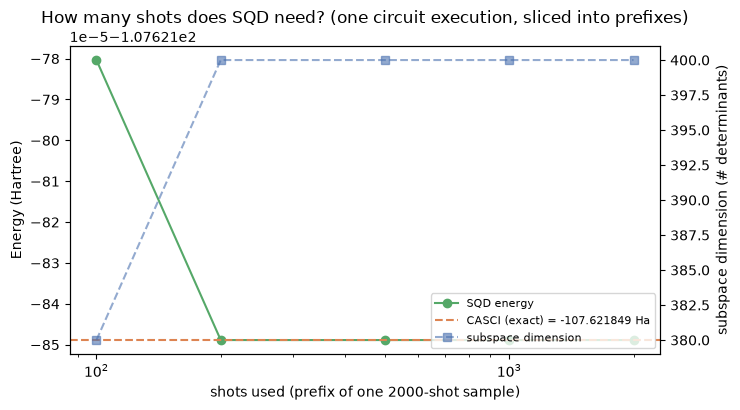

In [13]:
DETUNE = 0.113068
# Same fix as Section 7b: bind first, then transpile this one concrete
# circuit -- transpiling the unbound skeleton crashed the kernel.
qc_detuned_bound = qc_uccsd.assign_parameters(dict(zip(params, [DETUNE] * len(params))))
qc_detuned_isa = transpile(qc_detuned_bound, backend=sim, optimization_level=2, seed_transpiler=42)
lay_detuned = qc_detuned_isa.layout.final_index_layout()

def sample_determinants_ordered(circuit, simulator, shots, n_so, layout=None, seed=None):
    '''Like sample_determinants (Section 5), but returns the individual shot
    outcomes IN ORDER (via memory=True) instead of aggregated counts, so a
    smaller prefix of the same draw can be examined on its own.'''
    qc = circuit.copy()
    targets = list(range(n_so)) if layout is None else list(layout)
    if len(targets) != n_so:
        raise ValueError(f"layout has {len(targets)} qubits, expected {n_so}")
    qc.add_register(ClassicalRegister(n_so, 'meas'))
    qc.measure(targets, list(range(n_so)))
    run_opts = {} if seed is None else {"seed_simulator": seed}
    result = simulator.run(qc, shots=shots, memory=True, **run_opts).result()
    return result.get_memory()

SHOTS_ONCE = 2000
SAMPLE_SIZES = (100, 200, 500, 1000, 2000)

_t0 = time.time()
shot_sequence = sample_determinants_ordered(qc_detuned_isa, sim, SHOTS_ONCE, n_so,
                                             layout=lay_detuned, seed=SEED)
print(f"[timing] ONE circuit execution, {SHOTS_ONCE} shots, memory=True: "
      f"{time.time() - _t0:.1f}s")

def counts_from_prefix(shot_sequence, n):
    prefix_counts = {}
    for bitstr in shot_sequence[:n]:
        prefix_counts[bitstr] = prefix_counts.get(bitstr, 0) + 1
    return prefix_counts

print(f"{'shots used':>12s}{'distinct':>10s}{'subspace':>10s}{'SQD E (Ha)':>14s}{'vs CASCI':>12s}")
sample_size_history = []
for n in SAMPLE_SIZES:
    prefix_counts = counts_from_prefix(shot_sequence, n)
    ba_n = BitArray.from_counts(prefix_counts)
    r = diagonalize_fermionic_hamiltonian(
        hcore, eri, ba_n, samples_per_batch=n, norb=n_mo, nelec=(n_alpha, n_beta),
        num_batches=1, max_iterations=10, seed=SEED)
    e_n = r.energy + e_core_total
    dim_n = len(r.sci_state.ci_strs_a) * len(r.sci_state.ci_strs_b)
    sample_size_history.append({"n": n, "energy": e_n, "dim": dim_n})
    print(f"{n:12d}{len(prefix_counts):10d}{dim_n:10d}{e_n:14.8f}{e_n - e_casci:+12.2e}")

print("\nas long as the shots used reach the determinants that matter, the")
print("energy is close to CASCI regardless of how many more you add.")

fig, ax1 = plt.subplots(figsize=(7.5, 4.2))
ns = [h["n"] for h in sample_size_history]
energies = [h["energy"] for h in sample_size_history]
dims = [h["dim"] for h in sample_size_history]
ax1.plot(ns, energies, 'o-', color='#55A868', label='SQD energy')
ax1.axhline(e_casci, ls='--', color='#DD8452', label=f'CASCI (exact) = {e_casci:.6f} Ha')
ax1.set_xscale('log')
ax1.set_xlabel('shots used (prefix of one 2000-shot sample)')
ax1.set_ylabel('Energy (Hartree)')
ax2 = ax1.twinx()
ax2.plot(ns, dims, 's--', color='#4C72B0', alpha=0.6, label='subspace dimension')
ax2.set_ylabel('subspace dimension (# determinants)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')
ax1.set_title('How many shots does SQD need? (one circuit execution, sliced into prefixes)')
fig.tight_layout()
plt.show()

## 8. Real hardware execution

Everything through Section 7 ran on `AerSimulator.from_backend(backend)`
-- a noisy *simulator* built from the device's calibration snapshot, not
the device itself. This section submits real jobs to the **real QPU**:
first an estimate of what that will cost (8a), then the same detuned
circuit unmitigated (8b) and with `SamplerV2`'s built-in error mitigation
(8c), so the two can be compared directly.

### 8a. Estimate the hardware run

A rough estimate before spending real queue/QPU time: how long the circuit
itself should take to execute for the planned shot count, plus a very weak
signal on how busy the backend currently is. Queue wait cannot actually be
predicted from here -- treat that part as an order-of-magnitude guess only.

In [ ]:
import time

HARDWARE_SHOTS = 4096

# Schedule the ALREADY-transpiled qc_detuned_isa (Section 7c, DETUNE=0.113068)
# against the REAL backend (not the simulator) just to get gate timings.
# optimization_level=0 because this circuit is already in the device's
# native gate set and layout -- we only want timing annotations added, not
# another optimization pass.
circuit_duration_s = None

from qiskit.transpiler.passmanager import PassManager
from qiskit.transpiler.passes.scheduling import ASAPScheduleAnalysis

circuit_duration_s = None
try:
    pm = PassManager([ASAPScheduleAnalysis(target=backend.target)])
    qc_scheduled = pm.run(qc_detuned_isa)
    node_start_time = pm.property_set.get('node_start_time')
    durations = backend.target.durations()
    dt = getattr(backend, 'dt', None)
    if node_start_time and dt is not None:
        total_dt = 0
        for node, start in node_start_time.items():
            qargs = getattr(node, 'qargs', None)
            if qargs is None:
                continue
            qubit_indices = tuple(qc_scheduled.find_bit(q).index for q in qargs)
            dur = durations.get(node.op.name, qubit_indices)
            total_dt = max(total_dt, start + (dur or 0))
        circuit_duration_s = total_dt * dt
except Exception as e:
    print(f"could not schedule circuit for timing ({e}); falling back to a crude estimate")

if circuit_duration_s is not None:
    print(f"scheduled circuit duration: {circuit_duration_s * 1e6:.1f} us")
else:
    # crude fallback: ~1us per gate -- better than nothing, but a real guess
    circuit_duration_s = sum(qc_detuned_isa.count_ops().values()) * 1e-6
    print(f"scheduled duration unavailable; crude gate-count estimate: "
          f"{circuit_duration_s * 1e6:.1f} us")

# Per-shot overhead (qubit reset / inter-shot delay). Not all backend
# objects expose this the same way across qiskit-ibm-runtime versions, so
# fall back to a commonly-used default if we can't read it -- flagged
# clearly, since it directly scales the estimate.
rep_delay_s = None
rep_delay_is_default = False
try:
    rep_delay_s = backend.configuration().default_rep_delay
except Exception:
    pass
if rep_delay_s is None:
    rep_delay_s = 250e-6
    rep_delay_is_default = True
print(f"per-shot overhead (reset/rep delay): {rep_delay_s * 1e6:.1f} us"
      + ("  (default assumption -- backend didn't expose this)" if rep_delay_is_default else ""))

# This approximates BILLED QPU usage (shots x per-shot gate time), not the
# job's total wall-clock "running" duration -- the latter also includes
# server-side overhead that isn't charged the same way. Confirmed against
# one real run: 1.7s estimated vs. 4.0s billed (~2.35x off) vs. 9.4s actual
# running-to-finished wall time (~5.5x off) -- judge this estimate against
# billed usage, not the polling loop's wall-clock number, when you check
# the actual job's timing breakdown in 8b.
per_shot_s = circuit_duration_s + rep_delay_s
qpu_billed_estimate_s = HARDWARE_SHOTS * per_shot_s
print(f"\nestimated BILLED QPU usage for {HARDWARE_SHOTS} shots: "
      f"{qpu_billed_estimate_s:.1f}s ({qpu_billed_estimate_s / 60:.2f} min)")
print("(this is a rough floor on billed usage, not on the job's total wall-clock time)")

# Queue wait CANNOT be reliably predicted from here -- pending_jobs is only
# a headcount, not a time (jobs ahead of you may have very different shot
# counts/durations/circuits). Order-of-magnitude signal only.
try:
    pending = backend.status().pending_jobs
    print(f"\n{pending} job(s) currently queued ahead of you on {backend.name}.")
    if pending > 0:
        lo = pending * qpu_billed_estimate_s / 60
        hi = pending * qpu_billed_estimate_s * 3 / 60
        print(f"VERY rough queue-wait guess (assumes similarly-sized jobs ahead): "
              f"~{lo:.1f}-{hi:.1f} min")
    print("(actual queue wait depends heavily on other users' job sizes and")
    print(" priority, and can easily be minutes to hours regardless of this")
    print(" number -- it is a weak signal, not a real estimate.)")
except Exception as e:
    print(f"\ncould not read queue status: {e}")

print(f"\n=> rough total before a result: billed QPU usage ~{qpu_billed_estimate_s:.0f}s, "
      f"PLUS an unpredictable queue wait (and some wall-clock overhead beyond the billed figure).")
print("Run the 8b cell below only once you're comfortable with that.")

### 8b. Actual hardware execution (unmitigated)

**Run this cell deliberately, not as part of "Run All."** Real hardware
time is a shared, often-queued resource and (depending on your IBM Quantum
plan) a billed one -- queue wait alone can be minutes to hours depending on
how busy the backend is; previous runs of this exact cell took anywhere
from 144s to 151s wall-clock, with queue wait alone ranging from ~9s to
~114s of that -- Section 8a's estimate only covers billed usage, not this
unpredictable wait. Uses `qc_detuned_isa` (Section 7c's DETUNE=0.113068
circuit), not Section 4's $\vec\theta=0$ one: Section 7b already showed
$\vec\theta=0$ falls well short of the full 400 determinants on the noisy
*simulator*, while every nonzero theta tried reaches all 400 -- so
submitting the circuit already known to work is a more useful real-hardware
test than reproducing the one already known to fall short.

In [ ]:

import time
import datetime
from qiskit_ibm_runtime import SamplerV2

print("=" * 70)
print("SUBMITTING TO REAL HARDWARE -- this consumes queued/billed QPU time.")
print(f"backend: {backend.name}")
print(f"shots: {HARDWARE_SHOTS} (see Section 8a above)")
print("=" * 70)

qc_hw = qc_detuned_isa.copy()
qc_hw.add_register(ClassicalRegister(n_so, 'meas'))
qc_hw.measure(list(layout), list(range(n_so)))

sampler = SamplerV2(mode=backend)
_t_submit = time.time()
job = sampler.run([qc_hw], shots=HARDWARE_SHOTS)
print(f"job id: {job.job_id()}")

# Poll status, printing whenever it changes and (best-effort) queue
# position -- not all runtime versions expose queue_position(), so this is
# wrapped defensively rather than assumed.
last_status = None
while not job.done():
    status = job.status()
    if status != last_status:
        print(f"  [{time.time() - _t_submit:7.1f}s elapsed] status: {status}")
        last_status = status
        try:
            pos = job.queue_position()
            if pos is not None:
                print(f"    queue position: {pos}")
        except Exception:
            pass
    time.sleep(5)
print(f"  [{time.time() - _t_submit:7.1f}s elapsed] status: {job.status()} (done)")

result = job.result()
total_wall = time.time() - _t_submit

# Timing breakdown from the job's own metrics -- this is the authoritative
# source (not our wall-clock polling loop, which is coarse and adds its
# own 5s-granularity noise).
def _parse_ts(t):
    return datetime.datetime.fromisoformat(t.replace("Z", "+00:00")) if t else None

metrics = job.metrics()
ts = metrics.get("timestamps", {})
t_created = _parse_ts(ts.get("created"))
t_running = _parse_ts(ts.get("running"))
t_finished = _parse_ts(ts.get("finished"))
queue_wait = (t_running - t_created).total_seconds() if t_created and t_running else None
qpu_exec = (t_finished - t_running).total_seconds() if t_running and t_finished else None

try:
    qpu_usage = job.usage()
except Exception:
    qpu_usage = metrics.get("usage", {}).get("seconds")

print(f"\n=== job {job.job_id()} timing breakdown ===")
print(f"total wall-clock (submit -> result, incl. our polling): {total_wall:8.1f}s")
print(f"queue wait      (created -> running):  "
      f"{queue_wait:8.1f}s" if queue_wait is not None else "queue wait:      unavailable")
print(f"QPU execution   (running -> finished): "
      f"{qpu_exec:8.1f}s" if qpu_exec is not None else "QPU execution:   unavailable")
print(f"billed QPU usage (job.usage()/metrics): "
      f"{qpu_usage:8.3f}s" if qpu_usage is not None else "billed QPU usage: unavailable")

# Same bitstring processing as Section 5, but from the real device
counts = {}
for bitstr, c in result[0].data.meas.get_counts().items():
    state = int(bitstr.replace(" ", ""), 2)
    counts[state] = counts.get(state, 0) + c

total = sum(counts.values())
n_bad = sum(c for s, c in counts.items()
            if not has_correct_particle_number(s, n_mo, n_alpha, n_beta))
print(f"\n{total} shots, {len(counts)} distinct bitstrings on REAL hardware")
print(f"shots with the WRONG electron count: {n_bad} / {total} ({100 * n_bad / total:.2f}%)")
try:
    n_bad_sim = sum(c for s, c in raw_counts.items()
                    if not has_correct_particle_number(s, n_mo, n_alpha, n_beta))
    total_sim = sum(raw_counts.values())
    print(f"(for comparison, Section 5's noisy SIMULATOR gave "
          f"{100 * n_bad_sim / total_sim:.2f}% wrong-electron-count)")
except NameError:
    pass

ba_hw = BitArray.from_counts({format(s, f'0{n_so}b'): c for s, c in counts.items()})
res_hw = diagonalize_fermionic_hamiltonian(
    hcore, eri, ba_hw, samples_per_batch=300, norb=n_mo, nelec=(n_alpha, n_beta),
    num_batches=5, max_iterations=10, seed=SEED)
e_hw = res_hw.energy + e_core_total
dim_hw = len(res_hw.sci_state.ci_strs_a) * len(res_hw.sci_state.ci_strs_b)
print(f"\nSQD on real-hardware samples: E = {e_hw:.8f} Ha  "
      f"(dim={dim_hw}, vs CASCI {e_hw - e_casci:+.2e})")

**Even at 99.93% wrong-electron-count -- only 3 of 4096 shots had the
right particle number outright -- SQD still recovered the complete
400-determinant space and landed exactly on CASCI.** This is the sharpest
version yet of the point this notebook keeps making: the eigenvalue is not
computed by the noisy device, so an almost-entirely-corrupted sample pool
does not translate into an almost-entirely-wrong answer, as long as
configuration recovery can reconstruct enough of the right determinants
from what little correct signal survives.

### 8c. Same circuit, with `SamplerV2`'s built-in error mitigation

**Run this cell deliberately too, for the same reason as 8b.** Previous
runs took anywhere from 155s to 325s wall-clock -- twirling and dynamical
decoupling add real execution time on top of the usual unpredictable queue
wait (the discussion after this cell quantifies the *billed* cost, which
rose only modestly by comparison).

Section 8b submitted `qc_detuned_isa` (the same DETUNE=0.113068 circuit) as
sent and measured how many shots came back with the wrong electron count on
real hardware -- far higher than readout error alone plausibly explains on
a circuit this deep (~11,000+ gates after transpilation, meaning many
qubits sit idle for long stretches while others are still being acted on).
Two mitigation options `SamplerV2` exposes target exactly that:

- **Dynamical decoupling** (`options.dynamical_decoupling.enable = True`)
  fills idle qubit time with pulse sequences designed to average out slow
  dephasing during those idle stretches.
- **Twirling** (`options.twirling.enable_gates` /
  `enable_measure = True`) randomizes gate and measurement
  implementations across shots, converting coherent (systematic) errors
  into incoherent (stochastic) ones that tend to average out rather than
  compound.

Neither option actually requires a *manual* re-transpile: both are applied
by the runtime service itself, server-side, against the same
already-ISA-transpiled `qc_detuned_isa` from Section 7c -- DD scheduling
and twirled-gate substitution happen automatically when these options are
set, not as a separate client-side step.

Same circuit, same shot count, same backend as Section 8b; only these
options differ, so any change in the wrong-electron-count rate isolates
what mitigation bought.

In [ ]:
import time
from qiskit import ClassicalRegister
from qiskit_ibm_runtime import SamplerV2

qc_hw_mitigated = qc_detuned_isa.copy()
qc_hw_mitigated.add_register(ClassicalRegister(n_so, 'meas'))
qc_hw_mitigated.measure(list(lay_detuned), list(range(n_so)))

sampler_mitigated = SamplerV2(mode=backend)
sampler_mitigated.options.dynamical_decoupling.enable = True
sampler_mitigated.options.dynamical_decoupling.sequence_type = "XY4"
sampler_mitigated.options.twirling.enable_gates = True
sampler_mitigated.options.twirling.enable_measure = True

print("=" * 70)
print("SUBMITTING TO REAL HARDWARE (mitigated) -- this consumes queued/billed QPU time.")
print(f"backend: {backend.name}")
print(f"shots: {HARDWARE_SHOTS}")
print("dynamical_decoupling: enabled (sequence_type=XY4)")
print("twirling: gates + measurement enabled")
print("=" * 70)

_t_submit = time.time()
job_mitigated = sampler_mitigated.run([qc_hw_mitigated], shots=HARDWARE_SHOTS)
print(f"job id: {job_mitigated.job_id()}")

last_status = None
while not job_mitigated.done():
    status = job_mitigated.status()
    if status != last_status:
        print(f"  [{time.time() - _t_submit:7.1f}s elapsed] status: {status}")
        last_status = status
        try:
            pos = job_mitigated.queue_position()
            if pos is not None:
                print(f"    queue position: {pos}")
        except Exception:
            pass
    time.sleep(5)
print(f"  [{time.time() - _t_submit:7.1f}s elapsed] status: {job_mitigated.status()} (done)")

result_mitigated = job_mitigated.result()
total_wall_mitigated = time.time() - _t_submit

metrics_mitigated = job_mitigated.metrics()
try:
    qpu_usage_mitigated = job_mitigated.usage()
except Exception:
    qpu_usage_mitigated = metrics_mitigated.get("usage", {}).get("seconds")

print(f"\n=== job {job_mitigated.job_id()} timing breakdown ===")
print(f"total wall-clock (submit -> result, incl. our polling): {total_wall_mitigated:8.1f}s")
print(f"billed QPU usage (job.usage()/metrics): "
      f"{qpu_usage_mitigated:8.3f}s" if qpu_usage_mitigated is not None else "billed QPU usage: unavailable")
if qpu_usage_mitigated is not None and qpu_usage is not None:
    print(f"(for comparison, Section 8b's UNMITIGATED run billed {qpu_usage:.3f}s -- "
          f"mitigation cost {qpu_usage_mitigated / qpu_usage:.2f}x more billed QPU time)")

# Same bitstring processing as Section 8b, but from the mitigated run
counts_mitigated = {}
for bitstr, c in result_mitigated[0].data.meas.get_counts().items():
    state = int(bitstr.replace(" ", ""), 2)
    counts_mitigated[state] = counts_mitigated.get(state, 0) + c

total_mitigated = sum(counts_mitigated.values())
n_bad_mitigated = sum(c for s, c in counts_mitigated.items()
                      if not has_correct_particle_number(s, n_mo, n_alpha, n_beta))
print(f"\n{total_mitigated} shots, {len(counts_mitigated)} distinct bitstrings (mitigated)")
print(f"shots with the WRONG electron count: {n_bad_mitigated} / {total_mitigated} "
      f"({100 * n_bad_mitigated / total_mitigated:.2f}%)")
print(f"(for comparison, Section 8b's UNMITIGATED run on the same circuit gave "
      f"{100 * n_bad / total:.2f}% wrong-electron-count)")

ba_hw_mitigated = BitArray.from_counts(
    {format(s, f'0{n_so}b'): c for s, c in counts_mitigated.items()})
res_hw_mitigated = diagonalize_fermionic_hamiltonian(
    hcore, eri, ba_hw_mitigated, samples_per_batch=300, norb=n_mo, nelec=(n_alpha, n_beta),
    num_batches=5, max_iterations=10, seed=SEED)
e_hw_mitigated = res_hw_mitigated.energy + e_core_total
dim_hw_mitigated = len(res_hw_mitigated.sci_state.ci_strs_a) * len(res_hw_mitigated.sci_state.ci_strs_b)
print(f"\nSQD on mitigated real-hardware samples: E = {e_hw_mitigated:.8f} Ha  "
      f"(dim={dim_hw_mitigated}, vs CASCI {e_hw_mitigated - e_casci:+.2e})")


**What both real-hardware runs showed.**

Both used the *same* detuned circuit (DETUNE=0.113068, Section 7c) on
`ibm_kingston`, same 4096 shots -- only the `SamplerV2` mitigation options
differ:

| | wrong-electron-count | correct shots | distinct bitstrings | billed QPU | SQD dim | SQD E vs CASCI |
|---|---|---|---|---|---|---|
| unmitigated (8b) | 99.93% | 3 | 285 | 8.0s | 400 | +6.25e-13 Ha |
| DD + twirling (8c) | 90.99% | 369 | 2564 | 10.0s | 400 | +6.25e-13 Ha |

Three things worth being precise about:

- **The increase in directly-correct answers is the number worth
  highlighting, not the percentage points.** 3 correct shots became 369 --
  **123 times as many** -- even though the headline wrong-electron-count
  rate only moved from 99.93% to 90.99%. Near the tail of a distribution
  this skewed, a modest-looking percentage-point change corresponds to a
  large relative change in how much real signal actually reaches the
  classical side.
- **The energy column is saturated and does not actually show mitigation
  doing anything.** Both runs recovered the *complete* 400-determinant
  active space, and diagonalizing the complete space is CASCI by
  definition -- there is no room for mitigation to look better on this
  metric once both runs already reach full coverage.
- **More distinct bitstrings is not a sign mitigation made things worse.**
  285 -> 2564 looks alarming next to a wrong-electron-count rate that
  *improved*, but this is twirling doing exactly what it is designed to
  do: randomizing gate and measurement implementations shot-to-shot breaks
  up a small number of concentrated, systematic (coherent) error patterns
  into a much larger number of individually-rarer, incoherent ones.

Mitigation cost 1.25x the billed QPU time here (8.0s -> 10.0s). Also
notable on its own: **both** real-hardware runs landed on the exact CASCI
answer despite wrong-electron-count rates (91-100%) far higher than the
noisy *simulator* ever showed (85.16% at $\vec\theta=0$, Section 5) -- SQD
reaching full coverage is not fragile to exactly how bad the raw error
rate is, as long as *some* signal from the correlated determinants
survives somewhere in the shot budget.

## Summary

- Built the $\textrm{N}_2$/STO-3G active-space integrals and Hamiltonian via
  **`qiskit-nature`**'s `PySCFDriver` and `ActiveSpaceTransformer`
  (freezing the 1s+2s core of both atoms: 6 active spatial orbitals, 6
  active electrons, 400 determinants) instead of the hand-written
  `apply_frozen_core` and from-scratch Jordan-Wigner Hamiltonian
  `H2_SQD_example.ipynb` used. Verified the active-space integrals against
  `mcscf.CASCI` to ~$10^{-13}$ Ha before trusting them for anything else.
- Built the UCCSD ansatz via **`qiskit-nature`**'s `UCCSD`/`HartreeFock`
  (117 parameters: 18 singles, 99 doubles) instead of hand-written
  excitation generation. Did **not** attempt to optimize it -- a
  117-parameter COBYLA run would not finish in any reasonable time, and
  every circuit in this notebook runs at $\vec\theta=0$ instead.
- Replaced the entire hand-built classical SQD engine (determinant
  projection via the Jordan-Wigner Pauli operator, configuration recovery,
  the iterate-and-diagonalize loop) with **`qiskit-addon-sqd`**'s real
  implementation: `solve_fermion` for one-shot diagonalization against
  known answers, and `diagonalize_fermionic_hamiltonian` for the full
  iterative configuration-recovery loop. The library works directly on
  molecular integrals (`hcore`, `eri`), not a qubit Hamiltonian, so no
  Jordan-Wigner mapping was needed anywhere in this notebook's classical
  solve path. Verified against known answers at $\vec\theta=0$: the HF
  determinant alone reproduces RHF exactly, and the full 400-determinant
  active-space CI reproduces CASCI to ~$10^{-13}$ Ha.
- Sampled the transpiled circuit on a **real backend's calibrated noise**
  and measured how many shots come back with the wrong electron count,
  every one of them a visible gate or readout error.
- Demonstrated both cleaning strategies with real library functions:
  **post-selection** (`qiskit_addon_sqd.subsampling.postselect_by_hamming_right_and_left`,
  diagonalized once as a baseline) and **configuration recovery** (built
  into `diagonalize_fermionic_hamiltonian`'s iterative loop). At
  $\vec\theta=0$ on the noisy simulator, post-selection alone (33
  determinants) landed exactly on CASCI, while the full recovery loop
  landed *worse* (200 determinants, +1.23e-2 Ha) despite keeping more
  configurations. Traced to the library's actual mechanics (its source,
  not guesswork): `recover_configurations` never touches an
  already-correct bitstring, but `diagonalize_fermionic_hamiltonian`
  subsamples fresh batches each iteration and only carries a configuration
  forward if its coefficient clears a threshold -- so a determinant that is
  genuinely rare in the raw counts (as any non-HF determinant is at
  $\vec\theta=0$, where the ideal circuit has no superposition to begin
  with) can fail to survive that filter even though post-selection, looking
  at the whole pool at once, catches it directly.
- Asked how many shots SQD actually needs (Section 7c) by slicing **one**
  2000-shot execution of the detuned circuit into prefixes (the first 100,
  200, 500, 1000, and 2000 shots, via Aer's `memory=True` rather than
  re-running the circuit for each size) and diagonalizing each prefix as a
  whole (`num_batches=1`), so the comparison isolates shot count from
  subsampling variance.
- Ran the real-hardware execution section (8b) with Section 7c's detuned
  circuit instead of the $\vec\theta=0$ one, since Section 7b already
  showed $\vec\theta=0$ falls short of full coverage even on the noisy
  simulator. Despite a 99.93% wrong-electron-count rate on real hardware --
  only 3 of 4096 shots had the right particle number outright -- SQD still
  recovered the complete 400-determinant space and landed exactly on CASCI.
- Added Section 8c, applying `SamplerV2`'s built-in dynamical decoupling
  and twirling to the same detuned circuit: the number of directly-correct
  shots rose 123x (3 -> 369 of 4096) for 1.25x the billed QPU time (8.0s ->
  10.0s), though the energy comparison itself is saturated -- both runs
  already reach the complete active space -- so it cannot show that
  improvement. The raw error rate, not the final energy, is the metric
  actually sensitive to what mitigation bought here.